## Esercizio 1) SVD per la classificazione

### Consegna: 
Implementa il codice per classificare immagini di numeri, usando la SVD con basi di $k$ vettori.
- Considera due sole classi di immagini ("0" e "1") e calcola l'accuratezza delle predizioni di classificazione.
- Cambia le classi mantenendo la classificazione bi-classe (per esempio usa "0" e "9", oppure "3" e "8") e guarda come cambia l'accuratezza.
- Cambia $k$ e guarda come cambia l'accuratezza per le diverse coppie di classi.


### RECAP 

Nella decomposizione $A=U\Sigma V^T$:
- le colonne di $V$ descrivono lo spazio delle righe di $A$;
- le colonne di $U$ descrivono lo spazio delle colonne di $A$.

Nell’analisi dei dati, una matrice $A$ può corrispondere a un *dataset*:
- le righe di $A$ rappresentano generalmente le osservazioni; 
- le colonne di $A$ corrispondono alle caratteristiche misurate.

*Trovare i pattern dei dati richiede quindi studiare lo spazio delle righe di $A$!*

La SVD permette di rappresentare questi dati in un sottospazio di dimensione ridotta, individuato dai primi vettori singolari destri. Quando i dati sono centrati sottraendo la media di ciascuna caratteristica, questo procedimento realizza la Principal Component Analysis (PCA).

In questo esercizio utilizzeremo la SVD per classificare immagini di cifre scritte a mano, distinguendo gli “0” dagli “1”. In particolare:
- costruiremo una matrice con i dati della classe "0" e una matrice coi dati della classe "1";
- studieremo il sottospazio rappresentativo *di ciascuna classe* con la SVD;
- presa una nuova immagine, la proietteremo sul sottospazio di una classe (cioè ne cerchiamo la migliore approssimazione mediante i vettori della base di quella classe) e calcoliamo il residuo (la differenza) tra l’immagine originale e la sua proiezione;
- confronteremo i residui: più piccola è la sua norma, meglio quel sottospazio rappresenta l’immagine
- assegneremo l’immagine alla classe con il residuo di norma minore.


### Scikit-learn

Scikit-learn è una libreria Python per il machine learning: offre strumenti per classificazione, regressione, clustering e preparazione dei dati.

Occorre installare il pacchetto scikit-learn, poichè ne useremo i moduli `sklearn.datasets` e `sklearn.model_selection`. 

Per l'installazione da Terminale, con Conda: `conda install scikit-learn`
oppure con pip: `python -m pip install scikit-learn`

Attenzione: c'è una differenza tra il nome usato per l’installazione (scikit-learn) e quello usato nell’importazione (sklearn).

### Caricamento delle immagini

Il modulo `sklearn.datasets` contiene funzioni per caricare dataset di esempio o generare dati sintetici. Noi useremo il suo dataset `digits` contenente 1.797 immagini di cifre scritte a mano, da 0 a 9:
- `digits.data` sono immagini di 8 × 8 pixel trasformate in vettori di 64 valori (uno per pixel);
- `digits.target` è un vettore di etichette (una per ogni immagine), cioè contiene la cifra rappresentata (un numero da 0 a 9).


In [244]:
import numpy as np
from sklearn.datasets import load_digits

digits = load_digits()

X = digits.data
y = digits.target

# Normalizzazione dei pixel nell'intervallo [0, 1]
X = X / 16.0

print(type(X))
print("Dimensione dei dati:", X.shape)
print("Dimensione delle etichette:", y.shape)

<class 'numpy.ndarray'>
Dimensione dei dati: (1797, 64)
Dimensione delle etichette: (1797,)


Ogni riga di X rappresenta un’immagine. Vediamo ora un singolo dato:

In [245]:
print(X[0].shape)
print(f"X[0] = {X[0]}" )
print(f"y[0] = {y[0]}" )

(64,)
X[0] = [0.     0.     0.3125 0.8125 0.5625 0.0625 0.     0.     0.     0.
 0.8125 0.9375 0.625  0.9375 0.3125 0.     0.     0.1875 0.9375 0.125
 0.     0.6875 0.5    0.     0.     0.25   0.75   0.     0.     0.5
 0.5    0.     0.     0.3125 0.5    0.     0.     0.5625 0.5    0.
 0.     0.25   0.6875 0.     0.0625 0.75   0.4375 0.     0.     0.125
 0.875  0.3125 0.625  0.75   0.     0.     0.     0.     0.375  0.8125
 0.625  0.     0.     0.    ]
y[0] = 0


In [246]:
imm = X[0].reshape(8, 8)

print(imm.shape)
print(imm)

(8, 8)
[[0.     0.     0.3125 0.8125 0.5625 0.0625 0.     0.    ]
 [0.     0.     0.8125 0.9375 0.625  0.9375 0.3125 0.    ]
 [0.     0.1875 0.9375 0.125  0.     0.6875 0.5    0.    ]
 [0.     0.25   0.75   0.     0.     0.5    0.5    0.    ]
 [0.     0.3125 0.5    0.     0.     0.5625 0.5    0.    ]
 [0.     0.25   0.6875 0.     0.0625 0.75   0.4375 0.    ]
 [0.     0.125  0.875  0.3125 0.625  0.75   0.     0.    ]
 [0.     0.     0.375  0.8125 0.625  0.     0.     0.    ]]


Vediamo il dato come immagine con la funzione `plt.imshow`

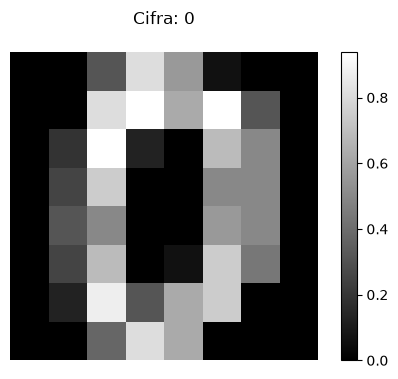

In [247]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.imshow(
    X[0].reshape(8, 8),     # immagine quadrata (formato originale)
    aspect="equal",         # impone la stessa scala sui due assi (quindi i pixel rimangono quadrati)
    cmap="gray"            # provare "gray" e "gray_r"
)
plt.colorbar()

plt.title(f"Cifra: {y[0]}\n"    )
plt.axis("off")
plt.show()



Guardiamo alle prime 10 immagini del dataset

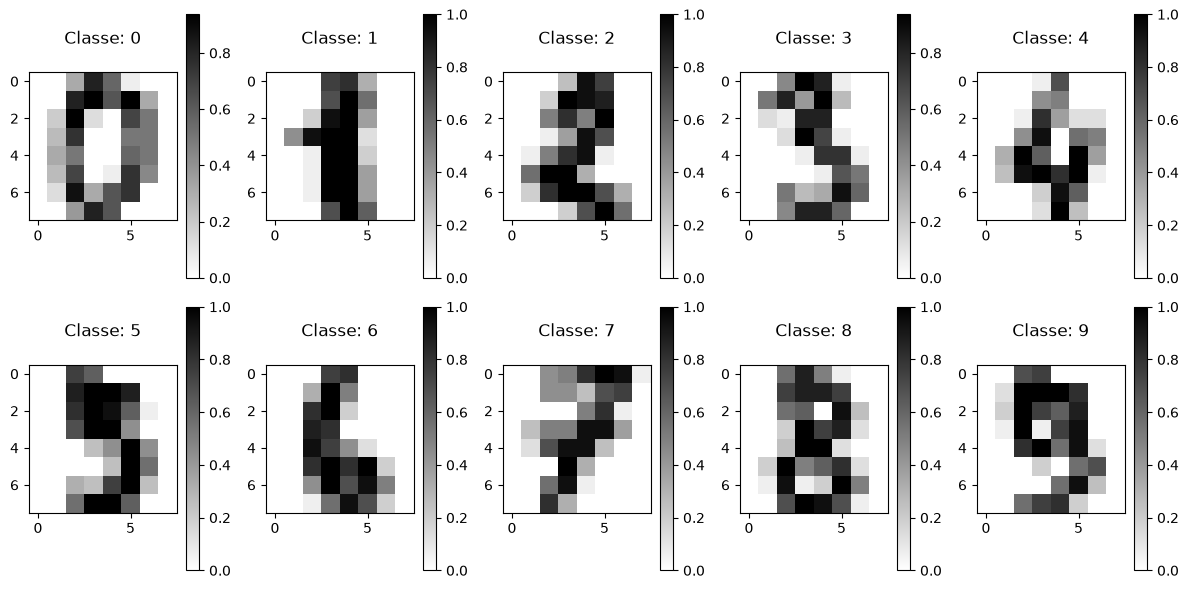

In [248]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for i in range(10):             

    plt.subplot(2, 5, i + 1)

    immagine = X[i].reshape(8, 8)

    plt.imshow(immagine, cmap="gray_r")
    plt.title(
        f"Classe: {y[i]}\n"
    )
    #plt.axis("off")
    plt.colorbar()

plt.tight_layout()
plt.show()

### Preprocessing (con selezione delle classi)

Per semplificare l'esercizio, consideriamo solo due classi di immagini: classe "0" e classe "1". Faremo quindi una classificazione bi-classe, lavorando su un dataset ridotto.  

In [249]:
# Selezioniamo soltanto le cifre 0 e 1
label0 = 0
label1 = 1

mask = (y == label0) | (y == label1)

X = X[mask]
y = y[mask]

print("Dimensione dei dati:", X.shape)
print("Dimensione delle etichette:", y.shape)

Dimensione dei dati: (360, 64)
Dimensione delle etichette: (360,)


In [250]:
mask_0 = y==label0
print(f"Numero di ZERI: {np.sum(mask_0)}")

mask_1 = y==label1
print(f"Numero di UNO: {np.sum(mask_1)}")


Numero di ZERI: 178
Numero di UNO: 182


Dividiamo poi i dati per training e test, in maniera equilibrata.

Il modulo `sklearn.model_selection` contiene strumenti per suddividere i dati, valutare e selezionare i modelli di Machine Learning. Ora usiamo `train_test_split`, una funzione che divide i dati in due gruppi:
  - Training set: per costruire o addestrare il modello.
  - Test set: per valutarlo su dati che non ha usato durante l’addestramento.


In [251]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y          # per manetenere la stessa proporzione di zeri e uno nei due insiemi
)

mask_0 = y_train==label0
print(f"Numero di ZERI nel train set: {np.sum(mask_0)}")

mask_1 = y_train==label1
print(f"Numero di UNO nel train set: {np.sum(mask_1)}")

Numero di ZERI nel train set: 125
Numero di UNO nel train set: 127


Costruiamo le due matrici delle due classi "0" e "1", ossia `A0` e `A1`. Ogni matrice contiene le proprie immagini e ogni immagine (64 pixel) rappresenta una riga.

In [252]:
A0 = X_train[y_train == label0]
A1 = X_train[y_train == label1]

print("Matrice della classe 0:", A0.shape)
print("Matrice della classe 1:", A1.shape)

Matrice della classe 0: (125, 64)
Matrice della classe 1: (127, 64)


### Funzioni per il classificatore SVD

In [253]:
def crea_base(A, k):
    """
    Calcola una base di dimensione k per le righe di A. 
    L'output è matrice B di dimensione  n × k (cioè 64 × k)
    """
    U, s, Vt = np.linalg.svd(A, full_matrices=False)
    B = Vt[:k, :].T         # prime k colonne di V (k righe di Vt)
    
    return B


def residuo(x, B):
    """
    Calcola la distanza di x dal sottospazio generato da B.
    """
    proiezione = B @ (B.T @ x)

    return np.linalg.norm(x - proiezione)


def classifica(x, B0, label0, B1, label1):
    """
    Assegna x alla classe con il residuo minore.
    """
    r0 = residuo(x, B0)
    r1 = residuo(x, B1)

    if r0 < r1:
        return label0
    else:
        return label1

### Classificazione

Calcolo le basi di `A0` e `A1`, con `k` vettori (train):

In [254]:
k = 5

B0 = crea_base(A0, k)
B1 = crea_base(A1, k)

print("Base della classe 0:", B0.shape)
print("Base della classe 1:", B1.shape)

Base della classe 0: (64, 5)
Base della classe 1: (64, 5)


Test:

In [ ]:
predizioni = []

for x in X_test:
    classe = classifica(x, B0, label0, B1, label1)
    predizioni.append(classe)

predizioni = np.array(predizioni)
print(predizioni)

[0 1 1 0 0 0 0 1 1 0 0 0 1 1 0 0 1 1 1 0 1 1 0 0 0 0 1 1 0 0 0 1 1 1 0 0 0
 0 1 1 0 0 1 0 1 1 1 1 0 0 0 0 1 0 1 1 0 1 0 1 0 1 1 0 0 0 1 1 0 1 0 1 0 0
 0 1 0 1 1 1 0 0 1 1 1 0 1 0 1 1 1 1 1 1 1 0 1 1 0 0 1 0 0 0 1 1 0 1]


Calcolo l'accuratezza:

In [256]:
print(y_test)

[0 1 1 0 0 0 0 1 1 0 0 0 1 1 0 0 1 1 1 0 1 1 0 0 0 0 1 1 0 0 0 1 1 1 0 0 0
 0 1 1 0 0 1 0 1 1 1 1 0 0 0 0 1 0 1 1 0 1 0 1 0 1 1 0 0 0 1 1 0 1 0 1 0 0
 0 1 0 1 1 1 0 0 1 1 1 0 1 0 1 1 1 1 1 1 1 0 1 1 0 0 1 0 0 0 1 1 0 1]


In [1]:
numCorretti = np.sum(predizioni == y_test)
print(numCorretti)
numTot = predizioni.size()
print(numTot)
print(f"Accuratezza: {numCorretti/numTot:.2%}")


# accuracy = np.mean(predizioni == y_test)
# print(f"Accuratezza: {accuracy:.2%}")

NameError: name 'np' is not defined

Visualizzo alcuni esempi:

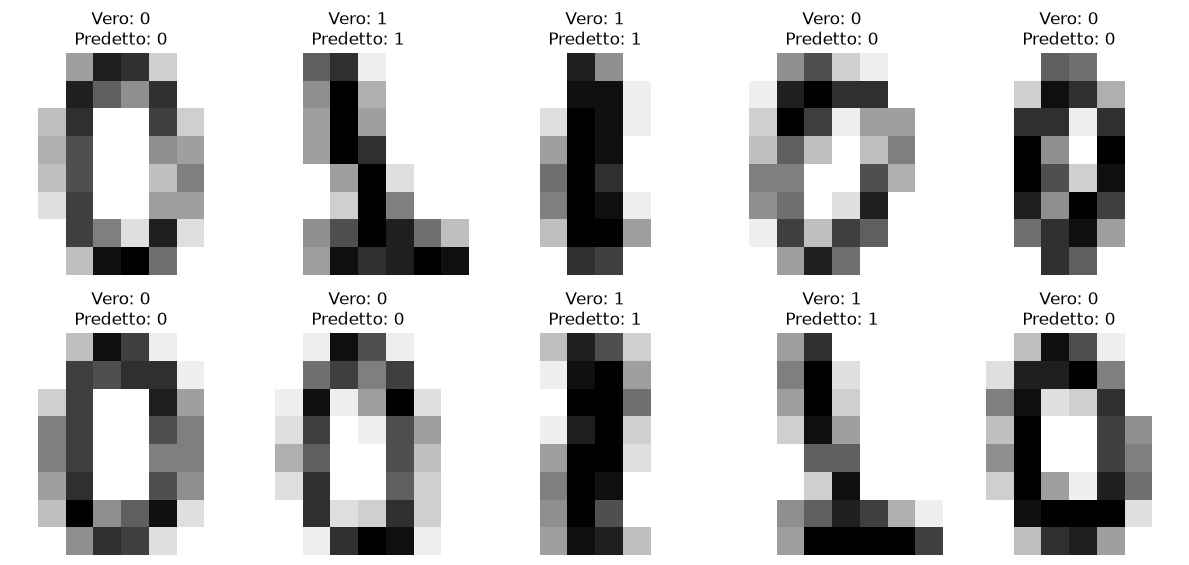

In [258]:
plt.figure(figsize=(12, 6))

for i in range(10):

    plt.subplot(2, 5, i + 1)

    immagine = X_test[i].reshape(8, 8)

    plt.imshow(immagine, cmap="gray_r")
    plt.title(
        f"Vero: {y_test[i]}\n"
        f"Predetto: {predizioni[i]}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

Calcolo la matrice di confusione, per confrontare le predizioni con le vere classi, con le funzioni apposite di scikit-learn.

[[53  0]
 [ 0 55]]


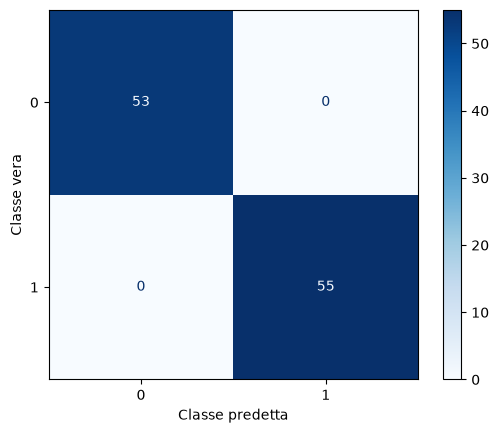

In [259]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, predizioni)
print(cm)

ConfusionMatrixDisplay(cm, display_labels=[label0, label1]).plot(cmap="Blues")
plt.xlabel("Classe predetta")
plt.ylabel("Classe vera")
plt.show()